<a href="https://colab.research.google.com/github/sarvisonker-jpg/Diabetes_Predicition/blob/main/Loan_Rejection_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans
import plotly.express as px
from scipy.stats.mstats import trimmed_var
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [56]:
df = pd.read_csv("/content/SCFP2019.csv")

In [57]:
df.head()

,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,6119.779308,2,75,6,12,4,2,0,...,5,3,6,3,2,10,6,6,3,3
1,1,12,4712.374912,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2
2,1,13,5145.224455,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2
3,1,14,5297.663412,2,75,6,12,4,2,0,...,5,2,6,2,1,10,4,4,2,2
4,1,15,4761.812371,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2


In [58]:
mask  =  df["TURNFEAR"] == 1
df_fear = df[mask]
print ("df_fear-shape : ",df_fear.shape)
df_fear.head()

df_fear-shape :  (4623, 351)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
5,2,21,3790.476607,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
6,2,22,3798.868505,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,3,2,2
7,2,23,3799.468393,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
8,2,24,3788.076005,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
9,2,25,3793.066589,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2


In [59]:
age_groups = df_fear["AGECL"].unique()
print("Age_Groups",age_groups)

Age_Groups [3 5 1 2 4 6]


In [60]:
agecl_dict = {
    1: "Under 35",
    2: "35-44",
    3: "45-54",
    4: "55-64",
    5: "65-74",
    6: "75 or Older"
}

age_cl = df_fear["AGECL"].replace(agecl_dict)
age_cl.head(10)

,AGECL
5,45-54
6,45-54
7,45-54
8,45-54
9,45-54
110,65-74
111,65-74
112,65-74
113,65-74
114,65-74


<Axes: xlabel='AGECL'>

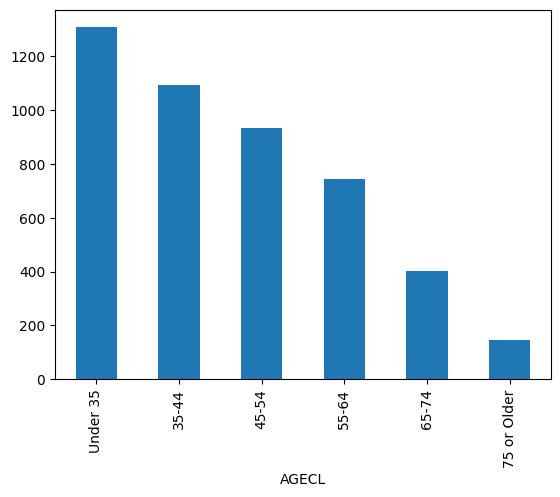

In [61]:
age_cl_value_counts = age_cl.value_counts()
age_cl_value_counts.plot(kind='bar')

<Axes: >

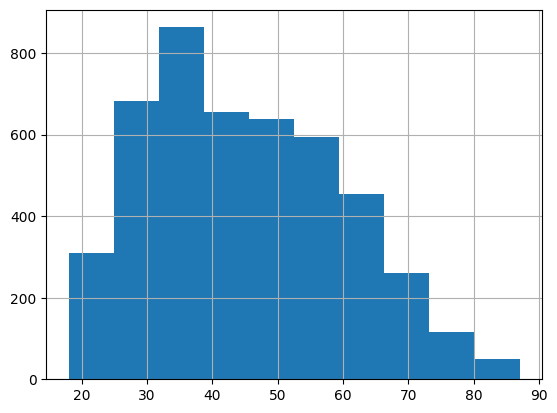

In [62]:
df_fear['AGE'].hist(bins=10)

In [63]:
inccat_dict = {
    1: "0-20",
    2: "20-39.9",
    3: "40-59.9",
    4: "60-79.9",
    5: "80-89.9",
    6: "90-100"
}
inccat = df_fear["INCCAT"].replace(inccat_dict)
inccat.head(10)

,INCCAT
5,20-39.9
6,20-39.9
7,20-39.9
8,20-39.9
9,20-39.9
110,0-20
111,0-20
112,0-20
113,0-20
114,0-20


<Axes: xlabel='INCCAT'>

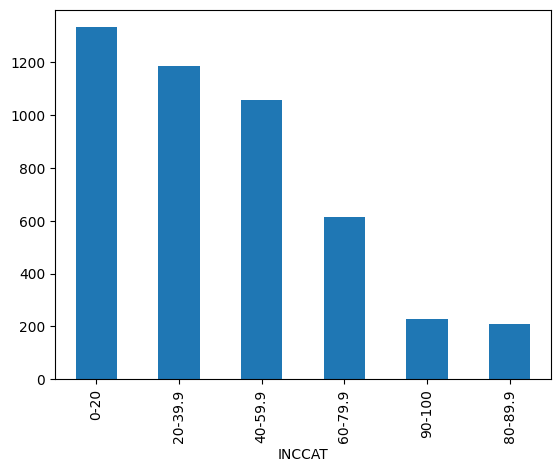

In [64]:
inccat_value_counts = inccat.value_counts()
inccat_value_counts.plot(kind='bar')

In [65]:
columns = ["ASSET","HOUSES","INCOME","DEBT","EDUC"]
corr = df[columns].corr()

corr.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.519827,0.622429,0.261250,0.116673
HOUSES,0.519827,1.000000,0.247852,0.266661,0.169300
INCOME,0.622429,0.247852,1.000000,0.114646,0.069400
DEBT,0.261250,0.266661,0.114646,1.000000,0.054179
EDUC,0.116673,0.169300,0.069400,0.054179,1.000000


In [66]:
corr_fear = df_fear[columns].corr()

corr_fear.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.583288,0.722074,0.474658,0.113536
HOUSES,0.583288,1.000000,0.264099,0.962629,0.160348
INCOME,0.722074,0.264099,1.000000,0.172393,0.133170
DEBT,0.474658,0.962629,0.172393,1.000000,0.177386
EDUC,0.113536,0.160348,0.133170,0.177386,1.000000


<Figure size 1200x600 with 0 Axes>

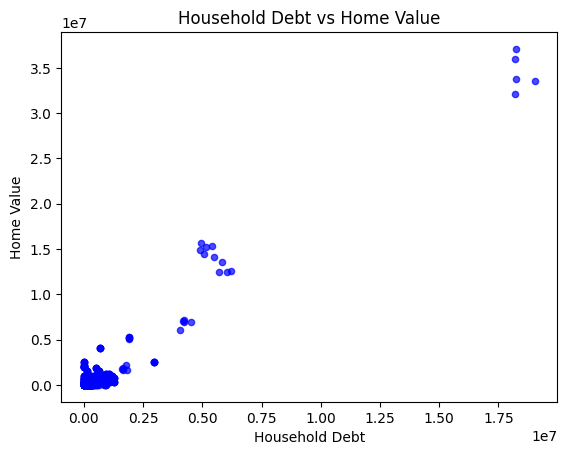

In [67]:
plt.figure(figsize=(12,6))
df_fear.plot.scatter(x='DEBT', y='HOUSES', c='blue', alpha=0.7, marker='o')
plt.xlabel('Household Debt')
plt.ylabel('Home Value')
plt.title('Household Debt vs Home Value')
plt.show()

In [68]:
df["TURNFEAR"].value_counts()

,count
TURNFEAR,
0,24262
1,4623


In [69]:
features = ["AGE", "INCCAT", "ASSETCAT"]
X = df[features]
X = X.dropna()

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

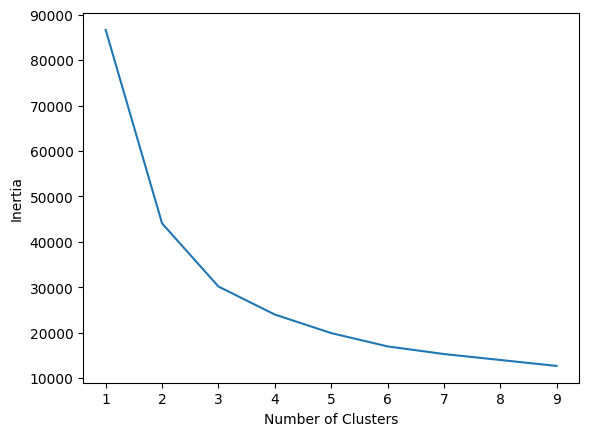

In [71]:
#Using K-Means Clustering for Model training and choosing the optimal K.
#This method is known as "The elbow Method"
#Tip - Look for the elbow bend in the graph.
inertia = {}

for k in range(1, 10):
    model = KMeans(n_clusters = k, random_state=42, n_init='auto')
    model.fit(X_scaled)
    inertia[k] = (model.inertia_)

plt.plot(range(1, 10), inertia.values())
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [72]:
# Training the final model now.
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

clusters = kmeans.labels_
X["Cluster"] = clusters
X.groupby("Cluster").mean()

,AGE,INCCAT,ASSETCAT
Cluster,,,
0,58.459248,5.396085,5.454231
1,35.583535,2.636474,2.060092
2,65.855628,2.092147,2.732592


In [73]:
labels = model.labels_
labels[:10]

array([4, 4, 4, 4, 4, 8, 8, 8, 8, 8], dtype=int32)

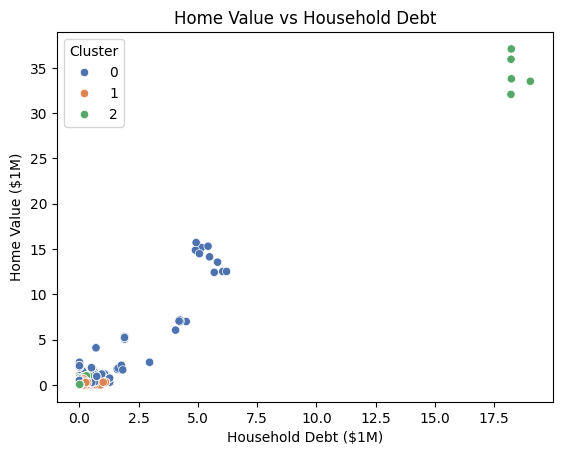

In [74]:
#Plotting "HOUSES" vs "DEBT" with hue = label
#Each dot in this scatter plot says "for this household, how much debt vs how much hous"
sns.scatterplot(
    x = df_fear["DEBT"] / 1e6,
    y = df_fear["HOUSES"] / 1e6,
    hue = X["Cluster"],
    palette = "deep"
)
plt.xlabel("Household Debt ($1M)")
plt.ylabel("Home Value ($1M)")
plt.title("Home Value vs Household Debt")

plt.show()

In [75]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4238
K = 3, Silhouette Score = 0.4103
K = 4, Silhouette Score = 0.3730
K = 5, Silhouette Score = 0.3689
K = 6, Silhouette Score = 0.3380
K = 7, Silhouette Score = 0.3203
K = 8, Silhouette Score = 0.3174
K = 9, Silhouette Score = 0.3195


# Conclusion

This project successfully implemented the K-Means Clustering algorithm on the given dataset. Data preprocessing, feature scaling, the Elbow Method, and the Silhouette Score were used to determine and evaluate the optimal clusters. The results demonstrate how K-Means clustering can identify meaningful patterns and group similar observations, making it a useful technique for exploratory data analysis and unsupervised machine learning.